In [24]:
import math
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [14]:
class Net(nn.Module):
    def __init__(self, layers=(1, 20, 1)):
        super().__init__()
        net = []
        for i in range(len(layers) - 2):
            net.append(nn.Linear(layers[i], layers[i+1]))
            net.append(nn.Tanh())
        net.append(nn.Linear(layers[-2], layers[-1]))
        self.net = nn.Sequential(*net)
    def forward(self, x):
        return self.net(x)

Consider the following ODE:
$$
\begin{cases}
u'' = (4\sigma^2(x - x_0)^2 - 2\sigma) e^{-\sigma(x-x_0)^2} \\
u(0) = e^{-\sigma x_0^2} \\
u(x_0) = 1
\end{cases}
$$

The solution is Gaussian function $u(x) = e^{-\sigma(x-x_0)^2}$

We consider the case of $\sigma=1$, $x_0 = 0$, thus system would look like this:
$$
\begin{cases}
u'' = (4x^2 - 2) e^{-x^2} \\
u(0) = 1
\end{cases}
$$
With the solution  $u(x) = e^{-x^2}$
The interval we takes is $x \in [0, 3]$

In [19]:
# --- Collocation points ---
N_f = 50
x_f = torch.rand(N_f, 1) * 3.0
x_f.requires_grad_()
f = ((4 * torch.pow(x_f, 2) - 2) * torch.exp(-torch.pow(x_f, 2))).detach()
u_exact = torch.exp(-torch.pow(x_f, 2)).detach()

# --- Boundary points ---
x_bc = torch.cat([torch.zeros(5, 1), torch.full((5, 1), 3.0)], dim=0)
u_bc = torch.cat([torch.ones(5, 1), torch.full((5, 1), math.exp(-9))], dim=0)

In [20]:
net = Net((1, 20, 50, 100, 50, 20, 1))

optimizer = optim.Adam(net.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.7)

mse_errors = []
l2_errors = []
l2_relative_errors = []

for epoch in range(6001):
    optimizer.zero_grad()

    # ODE residual
    u_f = net(x_f)
    u_x = torch.autograd.grad(u_f.sum(), x_f, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_f, torch.ones_like(u_x), create_graph=True)[0]

    loss_ode = torch.mean((u_xx - f)**2)

    # Boundary loss
    u_bc_pred = net(x_bc)
    loss_bc = torch.mean((u_bc - u_bc_pred)**2)

    loss = loss_ode + loss_bc
    loss.backward()
    optimizer.step()
    scheduler.step()

    # Compute errors ar current epoch
    l2_errors.append(torch.norm(u_f - u_exact).detach().item())
    l2_relative_errors.append(torch.norm(u_f - u_exact).detach().item() / torch.norm(u_exact).detach().item())
    mse_errors.append(torch.mean((u_f - u_exact) ** 2).detach().item())

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.7f}")
    # plot how error decreases with respect to learning rate

Epoch 0, Loss: 1.2281045
Epoch 1000, Loss: 0.0000482
Epoch 2000, Loss: 0.0000206
Epoch 3000, Loss: 0.0000129
Epoch 4000, Loss: 0.0000085
Epoch 5000, Loss: 0.0000054
Epoch 6000, Loss: 0.0000033


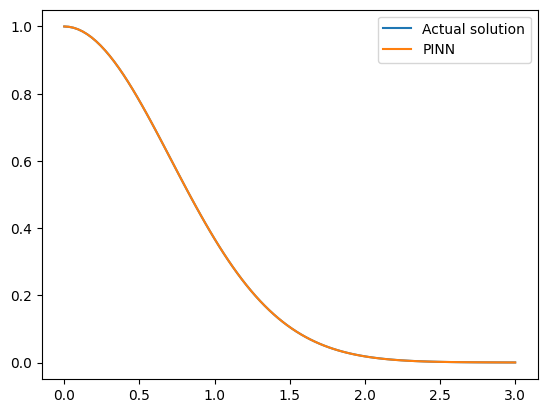

In [21]:
x_test = torch.linspace(0, 3, 100).reshape(-1, 1)

with torch.no_grad():
    u_pred = net(x_test)
    u_exact = torch.exp(-torch.pow(x_test, 2))

plt.plot(x_test, u_exact, label="Actual solution")
plt.plot(x_test, u_pred, label="PINN")
plt.legend()
plt.show()

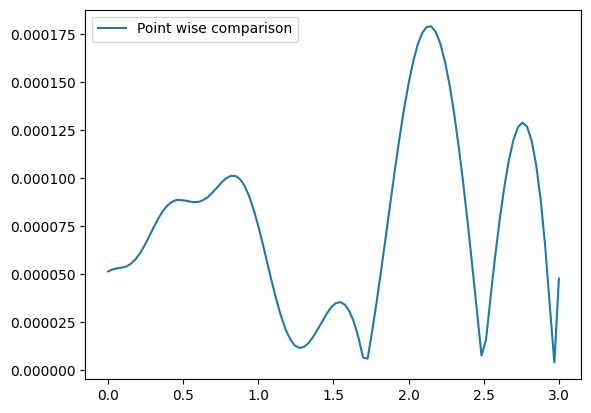

In [22]:
plt.plot(x_test, abs(u_pred - u_exact), label="Point wise comparison")
plt.legend()
plt.show()

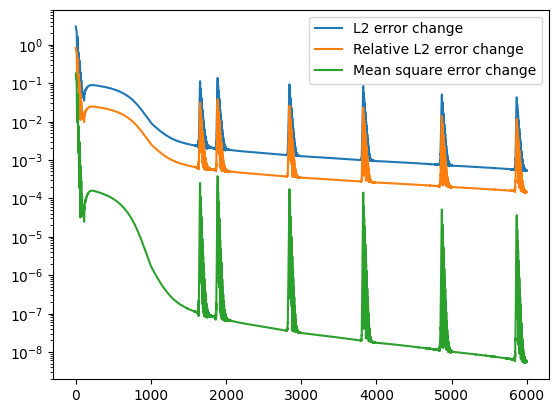

In [25]:
plt.semilogy(np.arange(0, 6001), l2_errors, label="L2 error change")
plt.semilogy(np.arange(0, 6001), l2_relative_errors, label="Relative L2 error change")
plt.semilogy(np.arange(0, 6001), mse_errors, label="Mean square error change")
plt.legend()
plt.show()

In [26]:
l2_error = torch.norm(u_pred - u_exact)
print(f"L2 error: {l2_error.item()}")
l2_relative_error = torch.norm(u_pred - u_exact) / torch.norm(u_exact)
print(f"Relative L2 error: {l2_relative_error.item()}")
mse = torch.mean((u_pred - u_exact)**2)
print(f"MSE: {mse.item()}")

L2 error: 0.0008802734664641321
Relative L2 error: 0.00019127485575154424
MSE: 7.748813146690736e-09
